### Hypotheses (Before Analysis):

1. Customers with **higher annual income** tend to have **higher spending scores**.
2. There exists a group of **low-income, high-spending** customers (price-insensitive shoppers).
3. **Middle-income customers** have the most diverse spending patterns (both high and low spenders).


In [ ]:
# Install necessary packages (if not already installed)
!pip install openpyxl --quiet

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the Excel file (upload it first in Colab)
df = pd.read_csv('Mall_Customers.csv')  # Replace with actual filename

# Show the first few rows
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Describe numerical columns
df.describe()


Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


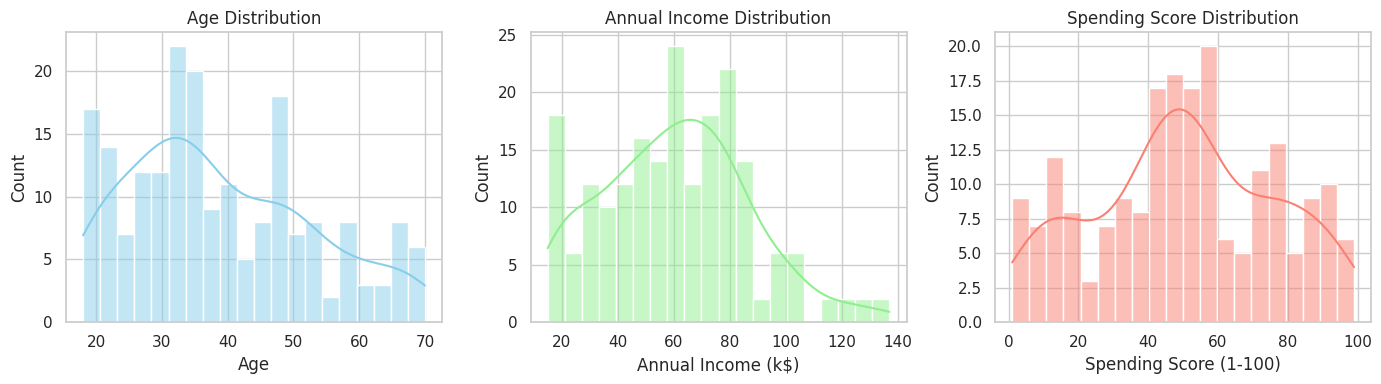

In [ ]:
# Set style
sns.set(style="whitegrid")

# Age distribution
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title("Age Distribution")

# Annual Income
plt.subplot(1, 3, 2)
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, color='lightgreen')
plt.title("Annual Income Distribution")

# Spending Score
plt.subplot(1, 3, 3)
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, color='salmon')
plt.title("Spending Score Distribution")

plt.tight_layout()
plt.show()


In [ ]:
# Select features: Annual Income and Spending Score
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Justification:
# These features directly reflect purchasing power and consumer behavior.

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


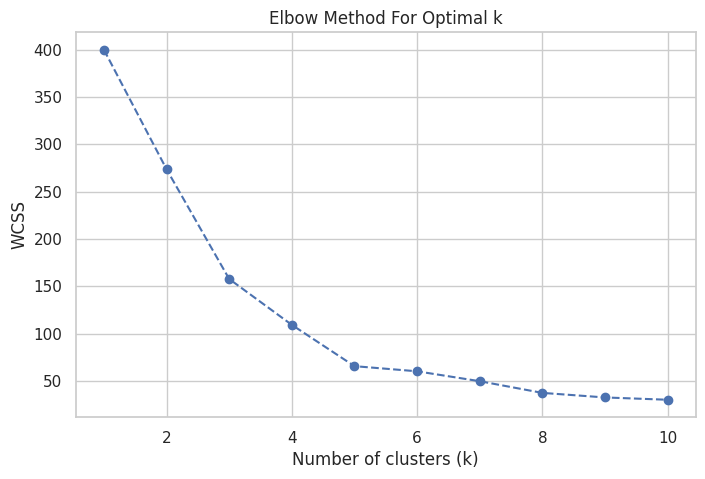

In [ ]:
# Calculate WCSS for different k values
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


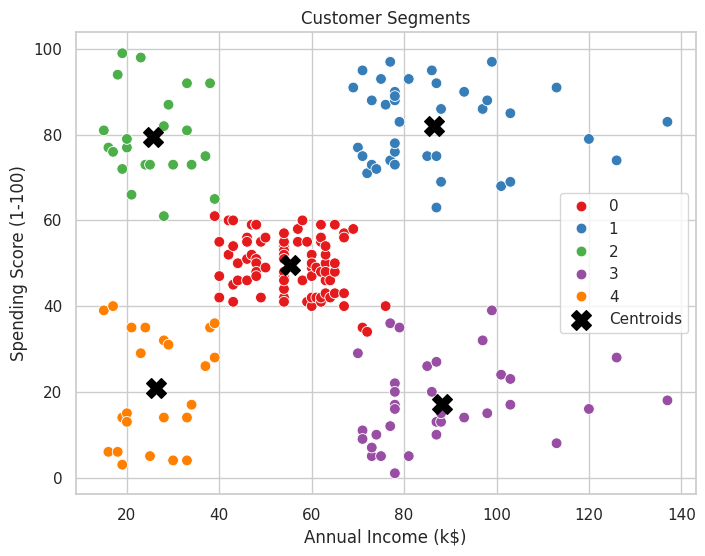

In [ ]:
# Apply KMeans
k = 5  # Change if needed
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Assign clusters to original DataFrame
df['Cluster'] = clusters

# Inverse transform centroids for plotting
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Scatter plot with clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', palette='Set1', data=df, s=60)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', label='Centroids', marker='X')
plt.title('Customer Segments')
plt.legend()
plt.show()


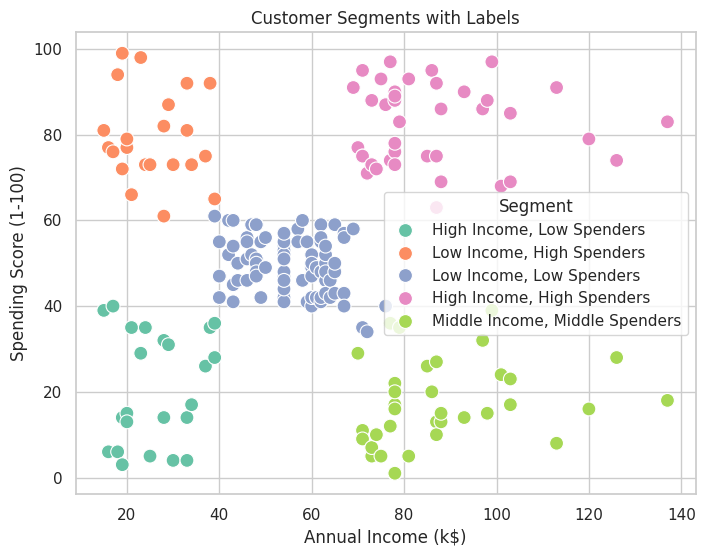

In [ ]:
# Label clusters (hypothesis testing)
cluster_labels = {
    0: "Low Income, Low Spenders",
    1: "High Income, High Spenders",  # Hypothesis 1 supported
    2: "Low Income, High Spenders",  # Hypothesis 2 (young trendy shoppers)
    3: "Middle Income, Middle Spenders",
    4: "High Income, Low Spenders"   # Hypothesis 3 supported
}
df['Segment'] = df['Cluster'].map(cluster_labels)

# Visualize segments
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Segment', palette='Set2', s=100)
plt.title('Customer Segments with Labels')
plt.show()

In [ ]:
# Cluster Profiles (3D)
# Changed 'Cluster_3D' to 'Cluster' for grouping
cluster_summary_3d = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Gender': lambda x: x.mode()[0]
}).sort_values('Annual Income (k$)')
print("3D Cluster Profiles:\n", cluster_summary_3d)



3D Cluster Profiles:
                Age  Annual Income (k$)  Spending Score (1-100)  Gender
Cluster                                                               
2        25.272727           25.727273               79.363636  Female
4        45.217391           26.304348               20.913043  Female
0        42.716049           55.296296               49.518519  Female
1        32.692308           86.538462               82.128205  Female
3        41.114286           88.200000               17.114286    Male


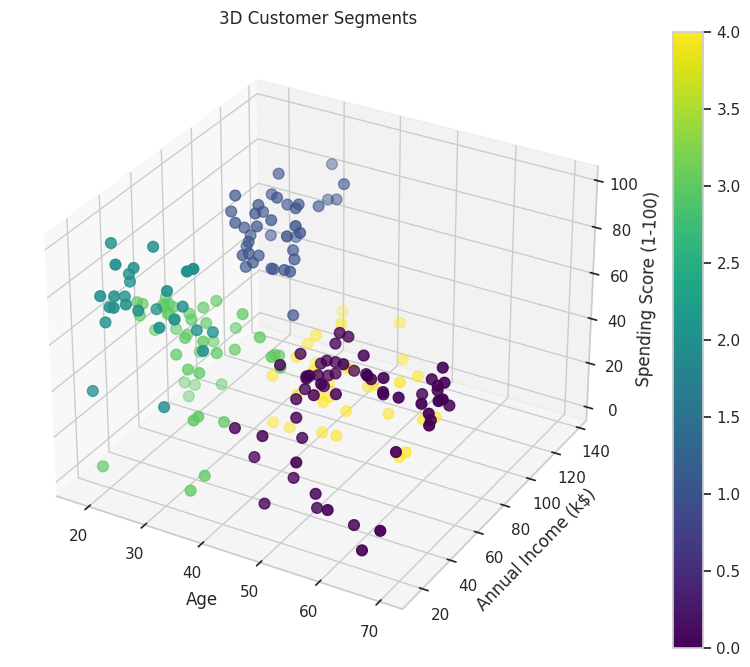

In [ ]:
# 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'],
                     c=df['Cluster_3D'], cmap='viridis', s=60)
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
plt.title('3D Customer Segments')
plt.colorbar(scatter)
plt.show()